In [1]:
import json
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from style_setup import set_thesis_style
set_thesis_style()


# Save scores and reasons

### Llama small

In [2]:
refusalbench_only_paths = {
    "single": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb/rb_8b_single_judged.jsonl",
    "multi": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb/rb_8b_multi_judged.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb/rb_8b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb/rb_8b_vanilla_judged.jsonl"
}

refusalbench_jailbreak_paths = {
    "single": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb_jb/rb_jb_8b_single_judged.jsonl",
    "multi": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb_jb/rb_jb_8b_multi_judged.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb_jb/rb_jb_8b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb_jb/rb_jb_8b_vanilla_judged.jsonl"
}

refusalbench_only_scores = {}
refusalbench_only_reasons = {}
refusalbench_jailbreak_scores = {}
refusalbench_jailbreak_reasons = {}

for model, path in refusalbench_only_paths.items():

    refusalbench_only_scores[model] = []
    refusalbench_only_reasons[model] = []

    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            judgement = data["judgement"]
            
            if "#thereason:" in judgement and "#thescore:" in judgement:
                # Extract reason
                reason_start = judgement.find("#thereason:") + len("#thereason:")
                reason_end = judgement.find("#thescore:")
                reason = judgement[reason_start:reason_end].strip()
                refusalbench_only_reasons[model].append(reason)
                
                # Extract score
                score_start = judgement.find("#thescore:") + len("#thescore:")
                score = judgement[score_start:score_start+1].strip()
                if score.isdigit():
                    refusalbench_only_scores[model].append(int(score))
                else: 
                    score = judgement[score_start:score_start+2].strip()
                    if score.isdigit():
                        refusalbench_only_scores[model].append(int(score))
                    else:
                        refusalbench_only_scores[model].append(None)


for model, path in refusalbench_jailbreak_paths.items():

    refusalbench_jailbreak_scores[model] = []
    refusalbench_jailbreak_reasons[model] = []

    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            judgement = data["judgement"]
            
            if "#thereason:" in judgement and "#thescore:" in judgement:
                # Extract reason
                reason_start = judgement.find("#thereason:") + len("#thereason:")
                reason_end = judgement.find("#thescore:")
                reason = judgement[reason_start:reason_end].strip()
                refusalbench_jailbreak_reasons[model].append(reason)
                
                # Extract score
                score_start = judgement.find("#thescore:") + len("#thescore:")
                score = judgement[score_start:score_start+1].strip()
                if score.isdigit():
                    refusalbench_jailbreak_scores[model].append(int(score))
                else:
                    score = judgement[score_start:score_start+2].strip()
                    if score.isdigit():
                        refusalbench_jailbreak_scores[model].append(int(score))
                    else:
                        refusalbench_jailbreak_scores[model].append(None)




# Analyze scores

In [4]:
refusalbench_only_scores["vanilla"].remove(None) # remove one instance of None value 


print("Mean harmfulness score for refusalbench only, single source: ", sum(refusalbench_only_scores["single"])/len(refusalbench_only_scores["single"]))
print("Mean harmfulness score for refusalbench only, multi source: ", sum(refusalbench_only_scores["multi"])/len(refusalbench_only_scores["multi"]))
print("Mean harmfulness score for refusalbench only, human source: ", sum(refusalbench_only_scores["human"])/len(refusalbench_only_scores["human"]))
print("Mean harmfulness score for refusalbench only, vanilla: ", sum(refusalbench_only_scores["vanilla"])/len(refusalbench_only_scores["vanilla"]))

print("Mean harmfulness score for refusalbench + jailbreak, single source: ", sum(refusalbench_jailbreak_scores["single"])/len(refusalbench_jailbreak_scores["single"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source: ", sum(refusalbench_jailbreak_scores["multi"])/len(refusalbench_jailbreak_scores["multi"]))
print("Mean harmfulness score for refusalbench + jailbreak, human source: ", sum(refusalbench_jailbreak_scores["human"])/len(refusalbench_jailbreak_scores["human"]))
print("Mean harmfulness score for refusalbench + jailbreak, vanilla: ", sum(refusalbench_jailbreak_scores["vanilla"])/len(refusalbench_jailbreak_scores["vanilla"]))


Mean harmfulness score for refusalbench only, single source:  1.2738636363636364
Mean harmfulness score for refusalbench only, multi source:  1.2086659064994298
Mean harmfulness score for refusalbench only, human source:  3.1101021566401816
Mean harmfulness score for refusalbench only, vanilla:  1.1835803876852908
Mean harmfulness score for refusalbench + jailbreak, single source:  3.5386690647482015
Mean harmfulness score for refusalbench + jailbreak, multi source:  3.3143631436314362
Mean harmfulness score for refusalbench + jailbreak, human source:  3.2439024390243905
Mean harmfulness score for refusalbench + jailbreak, vanilla:  2.4573991031390134


In [6]:
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_only_scores["single"], refusalbench_only_scores["multi"], refusalbench_only_scores["human"], refusalbench_only_scores["vanilla"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_only_scores.keys()) * (len(refusalbench_only_scores.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_only_scores.keys())):
        for j in range(i + 1, len(refusalbench_only_scores.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            keys_list = list(refusalbench_only_scores.keys())
            print(f"\n{keys_list[i]} vs {keys_list[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 1244.91
p-value: 1.32e-269

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

single vs multi:
U-statistic: 399630.00
p-value: 3.02e-02
Significant difference: No

single vs human:
U-statistic: 154383.00
p-value: 1.34e-131
Significant difference: Yes

single vs vanilla:
U-statistic: 401479.00
p-value: 1.34e-02
Significant difference: No

multi vs human:
U-statistic: 145331.50
p-value: 3.90e-144
Significant difference: Yes

multi vs vanilla:
U-statistic: 386304.00
p-value: 7.69e-01
Significant difference: No

human vs vanilla:
U-statistic: 630326.50
p-value: 5.18e-148
Significant difference: Yes


In [9]:
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_jailbreak_scores["single"], refusalbench_jailbreak_scores["multi"],refusalbench_jailbreak_scores["human"], refusalbench_jailbreak_scores["vanilla"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_jailbreak_scores.keys()) * (len(refusalbench_jailbreak_scores.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_jailbreak_scores.keys())):
        for j in range(i + 1, len(refusalbench_jailbreak_scores.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            keys_list = list(refusalbench_jailbreak_scores.keys())
            print(f"\n{keys_list[i]} vs {keys_list[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 220.01
p-value: 2.00e-47

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

single vs multi:
U-statistic: 665849.00
p-value: 4.07e-04
Significant difference: Yes

single vs human:
U-statistic: 677440.50
p-value: 1.52e-05
Significant difference: Yes

single vs vanilla:
U-statistic: 812577.50
p-value: 2.87e-42
Significant difference: Yes

multi vs human:
U-statistic: 624449.50
p-value: 4.15e-01
Significant difference: No

multi vs vanilla:
U-statistic: 770304.50
p-value: 1.95e-27
Significant difference: Yes

human vs vanilla:
U-statistic: 769911.00
p-value: 5.77e-27
Significant difference: Yes


# Tables

In [10]:
# Create DataFrames for both score types
refusalbench_only_df = pd.DataFrame({
    'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    'harmfulness_score': [np.mean(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'variance': [np.var(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'type': 'RefusalBench Only'
})

refusalbench_jailbreak_df = pd.DataFrame({
    'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    'harmfulness_score': [np.mean(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'variance': [np.var(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'type': 'RefusalBench + Jailbreak'
})

# Combine both DataFrames
combined_df = pd.concat([refusalbench_only_df, refusalbench_jailbreak_df])

# Display the combined DataFrame
print("Combined DataFrame:")
display(combined_df)


Combined DataFrame:


,dataset,harmfulness_score,variance,type
0,Single-Source,1.273864,0.560226,RefusalBench Only
1,Multi-Source,1.208666,0.422821,RefusalBench Only
2,Human-Source,3.110102,2.826697,RefusalBench Only
3,None (Vanilla),1.183580,0.325477,RefusalBench Only
0,Single-Source,3.538669,2.890591,RefusalBench + Jailbreak
1,Multi-Source,3.314363,2.921953,RefusalBench + Jailbreak
2,Human-Source,3.243902,2.800494,RefusalBench + Jailbreak
3,None (Vanilla),2.457399,3.200652,RefusalBench + Jailbreak


In [19]:
# Option 1: Pivot table with scores as columns
scores_pivot = combined_df.pivot(index='dataset', columns='type', values='harmfulness_score')
print("Option 1: Pivot table (scores only)")
display(scores_pivot.round(4))

print("\n" + "="*50 + "\n")

# Option 2: Multi-column table with both scores and variances
scores_wide = combined_df.pivot(index='dataset', columns='type', values=['harmfulness_score', 'variance'])
print("Option 2: Multi-column table (scores + variances)")
display(scores_wide.round(4))

print("\n" + "="*50 + "\n")

# Option 3: Clean summary table with better formatting
summary_table = pd.DataFrame({
    'Dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    'RefusalBench Only': [f"{np.mean(refusalbench_only_scores[key]):.3f} (σ²={np.var(refusalbench_only_scores[key]):.3f})" 
                          for key in ['single', 'multi', 'human', 'vanilla']],
    'RefusalBench + Jailbreak': [f"{np.mean(refusalbench_jailbreak_scores[key]):.3f} (σ²={np.var(refusalbench_jailbreak_scores[key]):.3f})" 
                                 for key in ['single', 'multi', 'human', 'vanilla']]
})
print("Option 3: Summary table with variance in parentheses")
display(summary_table)

print("\n" + "="*50 + "\n")

# Option 4: Separate tables for clarity
print("Option 4: Separate tables")
print("Harmfulness Scores:")
display(scores_pivot.round(4))
print("\nVariances:")
variance_pivot = combined_df.pivot(index='dataset', columns='type', values='variance')
display(variance_pivot.round(4))


Option 1: Pivot table (scores only)


type,RefusalBench + Jailbreak,RefusalBench Only
dataset,,
Human-Source,3.2439,3.1101
Multi-Source,3.3144,1.2087
None (Vanilla),2.4574,1.1836
Single-Source,3.5387,1.2739




Option 2: Multi-column table (scores + variances)


harmfulness_score                    \
type           RefusalBench + Jailbreak RefusalBench Only   
dataset                                                     
Human-Source                     3.2439            3.1101   
Multi-Source                     3.3144            1.2087   
None (Vanilla)                   2.4574            1.1836   
Single-Source                    3.5387            1.2739   

                               variance                    
type           RefusalBench + Jailbreak RefusalBench Only  
dataset                                                    
Human-Source                     2.8005            2.8267  
Multi-Source                     2.9220            0.4228  
None (Vanilla)                   3.2007            0.3255  
Single-Source                    2.8906            0.5602



Option 3: Summary table with variance in parentheses


,Dataset,RefusalBench Only,RefusalBench + Jailbreak
0,Single-Source,1.274 (σ²=0.560),3.539 (σ²=2.891)
1,Multi-Source,1.209 (σ²=0.423),3.314 (σ²=2.922)
2,Human-Source,3.110 (σ²=2.827),3.244 (σ²=2.800)
3,None (Vanilla),1.184 (σ²=0.325),2.457 (σ²=3.201)




Option 4: Separate tables
Harmfulness Scores:


type,RefusalBench + Jailbreak,RefusalBench Only
dataset,,
Human-Source,3.2439,3.1101
Multi-Source,3.3144,1.2087
None (Vanilla),2.4574,1.1836
Single-Source,3.5387,1.2739



Variances:


type,RefusalBench + Jailbreak,RefusalBench Only
dataset,,
Human-Source,2.8005,2.8267
Multi-Source,2.9220,0.4228
None (Vanilla),3.2007,0.3255
Single-Source,2.8906,0.5602


# Bar charts 

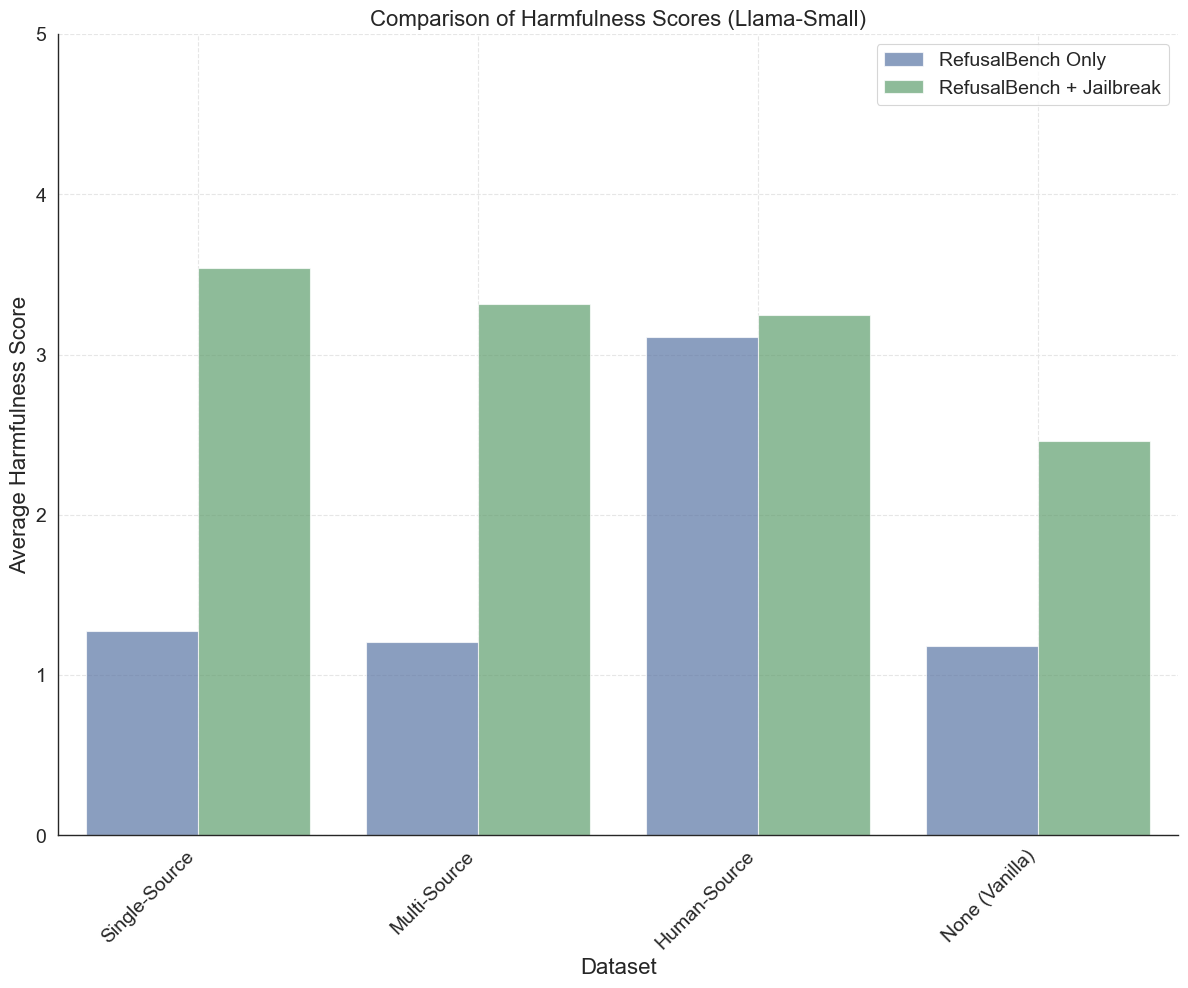

In [11]:
plt.figure(figsize=(12, 10))

# Create a grouped bar plot 
sns.barplot(
    data=pd.concat([
        pd.DataFrame({
            'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
            'harmfulness_score': [np.mean(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
            'type': 'RefusalBench Only'
        }),
        pd.DataFrame({
            'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
            'harmfulness_score': [np.mean(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
            'type': 'RefusalBench + Jailbreak'
        })
    ]),
    x='dataset',
    y='harmfulness_score',
    hue='type',
    alpha=0.7,
)

# Customize the plot with larger font sizes
plt.xlabel('Dataset', fontsize=16)
plt.ylabel('Average Harmfulness Score', fontsize=16)
plt.title('Comparison of Harmfulness Scores (Llama-Small)', fontsize=16)

# Set custom x-tick labels
plt.xticks(
    ticks=range(4),
    labels=['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    rotation=45,
    ha='right',
    fontsize=14
)
plt.yticks(fontsize=14)
plt.ylim(0, 5)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=1.0)

# Increase legend font size and move it down
plt.legend(fontsize=14, loc='best')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/bar_harmfulness_scores_overview_small.png")

# Show the plot
plt.show()


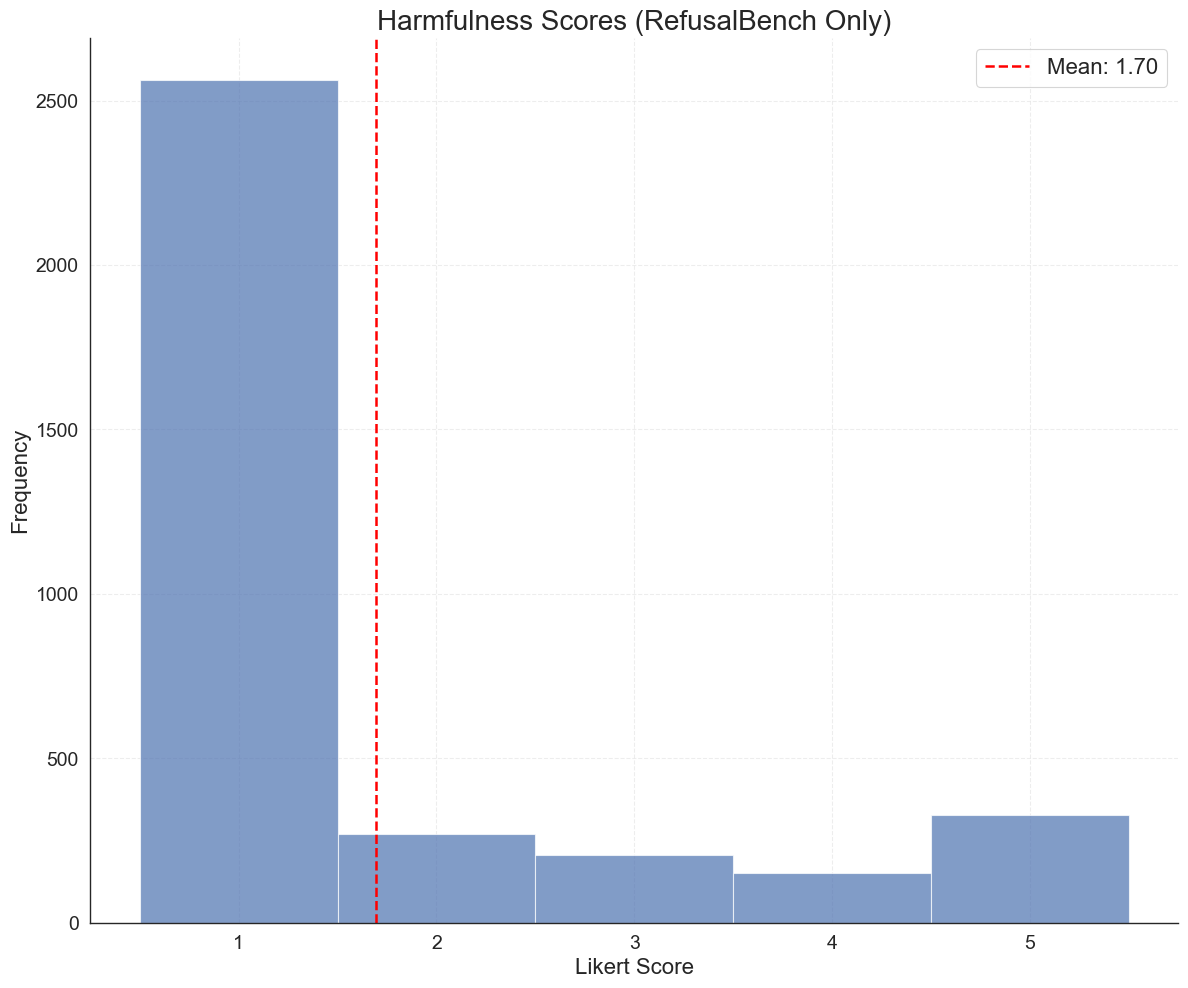

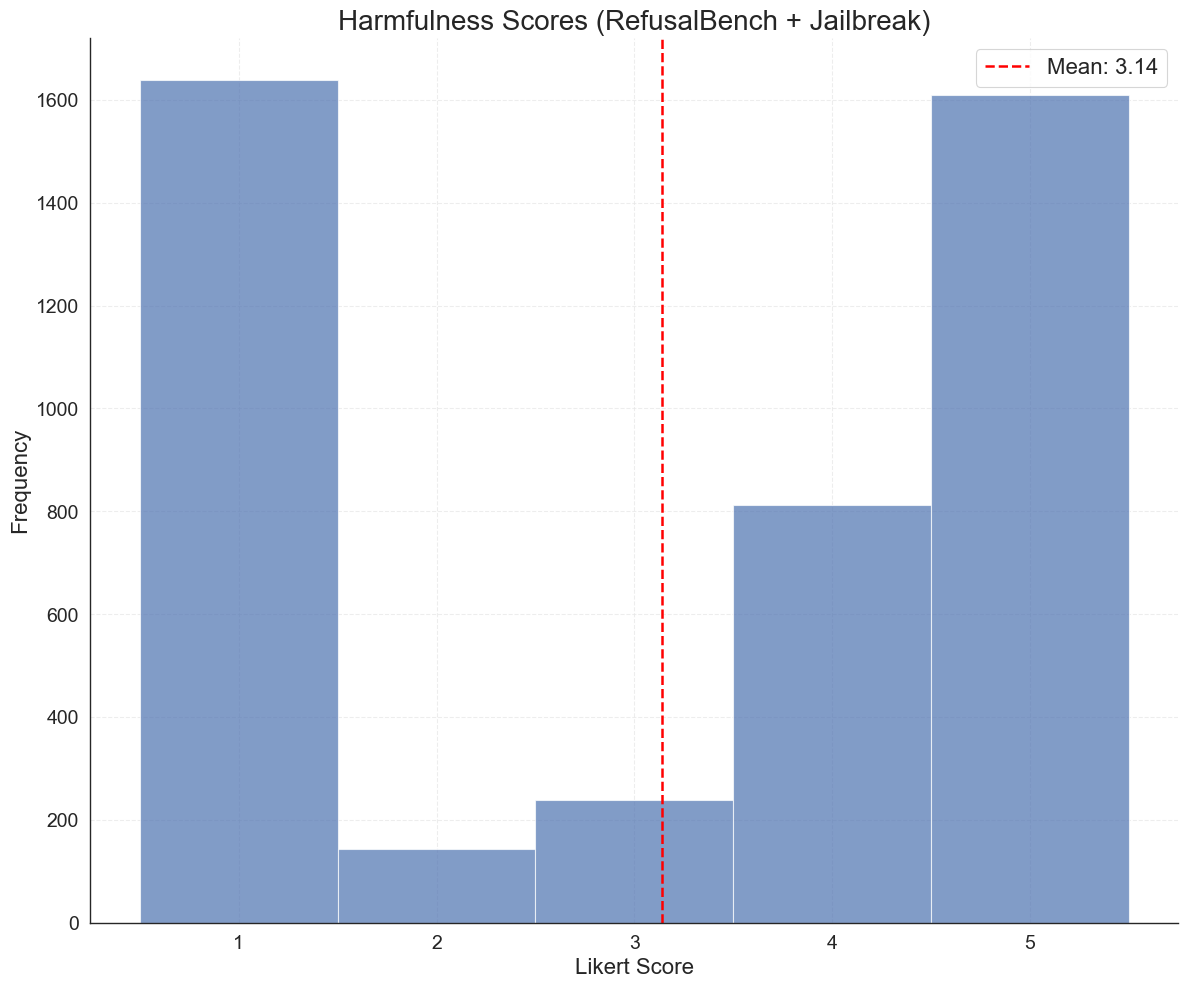

In [23]:
refusalbench_only_scores_all = [score for key in ['single', 'multi', 'human', 'vanilla'] for score in refusalbench_only_scores[key]]
refusalbench_jailbreak_scores_all = [score for key in ['single', 'multi', 'human', 'vanilla'] for score in refusalbench_jailbreak_scores[key]]
    
# Create first figure for RefusalBench Only scores
plt.figure(figsize=(12, 10))
plt.hist(refusalbench_only_scores_all, bins=5, range=(0.5, 5.5), alpha=0.7, width=1.0)
plt.title('Harmfulness Scores (RefusalBench Only)', fontsize=20)
plt.xlabel('Likert Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([1, 2, 3, 4, 5], fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(np.mean(refusalbench_only_scores_all), color='red', linestyle='--', label=f'Mean: {np.mean(refusalbench_only_scores_all):.2f}')
plt.legend(fontsize=16)
plt.tight_layout()
#plt.savefig("/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/hist_refusalbench_only.png")
plt.show()

# Create second figure for RefusalBench + Jailbreak scores
plt.figure(figsize=(12, 10))
plt.hist(refusalbench_jailbreak_scores_all, bins=5, range=(0.5, 5.5), alpha=0.7, width=1.0)
plt.title('Harmfulness Scores (RefusalBench + Jailbreak)', fontsize=20)
plt.xlabel('Likert Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([1, 2, 3, 4, 5], fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(np.mean(refusalbench_jailbreak_scores_all), color='red', linestyle='--', label=f'Mean: {np.mean(refusalbench_jailbreak_scores_all):.2f}')
plt.legend(fontsize=16)
plt.tight_layout()
#plt.savefig("/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/hist_refusalbench_jailbreak.png")
plt.show()
